# Laboratorio Nro 03 - Regresión Logistica


In [36]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1 Regresion Logistica

La siguiente celda cargará los datos y las etiquetas correspondientes:

In [37]:
# 1. Cargar el dataset con Pandas

df = pd.read_csv('OnlineNewsPopularity.csv')

# Limpiar los nombres de las columnas (el dataset original tiene espacios en blanco al inicio)
df.columns = df.columns.str.strip()

# 2. Eliminar columnas que no sirven para predecir (url y timedelta)
df = df.drop(['url', 'timedelta'], axis=1)

# 3. Binarizar la variable objetivo 'shares' (1 = Popular, 0 = No Popular)
df['shares'] = (df['shares'] >= 1400).astype(int)

# Asegurarnos de que 'shares' esté en la última columna
col_y = df.pop('shares')
df.insert(len(df.columns), 'shares', col_y)

# 4. Convertir el DataFrame a matriz NumPy
data = df.values

# Mezclar los datos aleatoriamente para evitar sesgos
np.random.seed(42)
np.random.shuffle(data)

# Calcular dinámicamente el 80% (límite) y el número de columnas (n_cols)
limite = int(len(data) * 0.8)
n_cols = data.shape[1] - 1

# 5. División estricta 80/20 manteniendo el estilo de slicing de matrices
X_train, y_train = data[:limite, 0:n_cols], data[:limite, n_cols]
X_test, y_test = data[limite:, 0:n_cols], data[limite:, n_cols]

# Redefinir variables para el entrenamiento
X = X_train
y = y_train

print(f"Total de ejemplos (m): {len(data)}")
print(f"Total de propiedades (n): {n_cols}")
print(f"Ejemplos de Entrenamiento (80%): {len(y_train)}")
print(f"Ejemplos de Prueba (20%): {len(y_test)}")

Total de ejemplos (m): 39644
Total de propiedades (n): 58
Ejemplos de Entrenamiento (80%): 31715
Ejemplos de Prueba (20%): 7929


### 1.1 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Mostramos los datos en una gráfica bidimensional llamando a la función `plotData`. Se completará el código en `plotData` para que muestre una figura donde los ejes son los dos puntajes de los dos examenes, los ejemplos positivos y negativos se muestran con diferentes marcadores.

In [38]:
def plotData(X, y):
    # Grafica los puntos de datos X e y en una nueva figura. 
    # Grafica los datos con * para las noticias populares (1) y con o para las no populares (0).

    # Crea una nueva figura
    fig = plt.figure()

    # Encuentra los índices de los ejemplos positivos (Populares) y negativos (No Populares)
    pos = y == 1
    neg = y == 0

    # Grafica ejemplos tomando las dos primeras características de X
    # (Por defecto, índice 0: Palabras en el título, índice 1: Palabras en el contenido)
    plt.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    plt.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)

Se llama a la función implementada para mostrar los datos cargados:

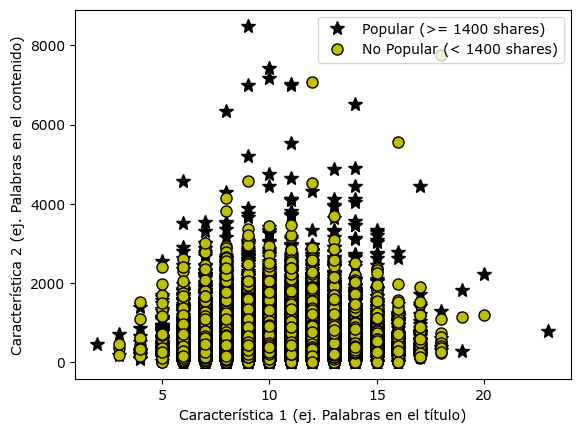

In [39]:
# Llama a la función implementada
plotData(X, y)

# Adiciona etiquetas para los ejes adaptadas al contexto de las noticias
plt.xlabel('Característica 1 (ej. Palabras en el título)')
plt.ylabel('Característica 2 (ej. Palabras en el contenido)')

# Leyenda adaptada a la popularidad de la noticia
plt.legend(['Popular (>= 1400 shares)', 'No Popular (< 1400 shares)'])
pass

<a id="section1"></a>
### 1.2 Implementacion

#### 1.2.1 Fución Sigmoidea


In [40]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z (probabilidad de que la noticia sea popular)
    # Convierte la entrada a un arreglo numpy de tipo float64 para mayor precisión
    z = np.array(z, dtype=np.float64)
    
    # np.clip limita los valores extremos para evitar desbordamientos matemáticos (overflow).
    # Esto es crucial al sumar 58 características diferentes del dataset de noticias.
    z = np.clip(z, -500, 500)
    
    g = np.zeros(z.shape)
    g = 1 / (1 + np.exp(-z))
    
    return g

Se calcula el valor de la sigmoide aplicando la funcion sigmoid con `z=0`, se debe obtener un resultado de 0.5. RE recomienda experimentar con otros valores de `z`.

In [41]:
# Prueba la implementación de la función sigmoid con valores de ejemplo
z = [0, 0.5, 0.75, 1]
g = sigmoid(z)
print('Probabilidades de prueba: g(', z, ') = ', g)

Probabilidades de prueba: g( [0, 0.5, 0.75, 1] ) =  [0.5        0.62245933 0.6791787  0.73105858]


In [42]:
def featureNormalize(X):
    # Normaliza las características de los artículos (escala los valores como cantidad de palabras, enlaces, etc.)
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Protección matemática: Si alguna columna del dataset de noticias tiene siempre el mismo valor 
    # (desviación estándar = 0), evitamos la división por cero reemplazando ese 0 por un 1.
    sigma[sigma == 0] = 1
    
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [43]:
# Llama a featureNormalize con los datos de entrenamiento (características de las noticias)
X_norm, mu, sigma = featureNormalize(X)

In [44]:
print("Características de las noticias normalizadas (Muestra de los primeros 3 artículos):")
print(X_norm[:3])

Características de las noticias normalizadas (Muestra de los primeros 3 artículos):
[[ 7.60665076e-01  1.00690312e+00 -7.93088068e-01  1.75438702e-01
  -8.30120589e-01 -7.65937815e-02  7.13082733e-01  3.43023692e+00
  -6.05675294e-02  1.29061467e-01 -1.68629970e+00 -2.35686570e-01
  -4.67535136e-01  2.31121865e+00 -2.48959797e-01 -4.78118066e-01
  -5.18560061e-01 -3.89252343e-01 -2.23763324e-01 -3.22064152e-01
  -1.21821838e-01  4.24343621e-01  1.02846980e+00  6.10144794e-01
  -3.50222912e-01 -3.02760272e-01 -1.46873329e-01  2.89164449e-01
   1.59188914e-03 -4.48642680e-01  2.09765017e+00 -4.78964007e-01
  -4.74281594e-01 -4.12773034e-01 -2.58116382e-01 -2.72216219e-01
  -3.89033209e-01  5.60408099e-01 -4.17370640e-01 -5.88740402e-01
  -5.86929913e-01  9.83137637e-01  2.39128599e-01  4.18763302e-01
   1.02424859e-01 -7.12467006e-01  7.44046448e-01 -7.14317396e-01
  -1.92555172e-01  6.35312997e-02  1.76474207e-01  7.72384226e-01
   7.28929544e-02  3.78891205e-01 -8.69741630e-01 -2.63301

<a id="section2"></a>
#### 1.2.2 Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [45]:
# Configurar la matriz adecuadamente, agregando una columna de unos que corresponde al término de intercepción.
m, n = X.shape

# Agrega el término de intercepción a X_norm (nuestra matriz de características de noticias)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [47]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores útiles
    m = y.size  # número de noticias en el entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    
    # Agregamos epsilon para evitar el error matemático log(0) al calcular el costo
    epsilon = 1e-15
    J = (1 / m) * np.sum(-y.dot(np.log(h + epsilon)) - (1 - y).dot(np.log(1 - h + epsilon)))

    return J

In [72]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # número de noticias en el entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()
    
    J_history = []
    acc_history = [] # NUEVO: Lista para guardar la evolución de la precisión

    for i in range(num_iters):
        # 1. Calcular la hipótesis
        h = sigmoid(X.dot(theta.T))
        
        # 2. Actualizar parámetros theta
        theta = theta - (alpha / m) * (h - y).dot(X)

        # 3. Guardar el costo actual
        J_history.append(calcularCosto(theta, X, y))
        
        # 4. NUEVO: Calcular y guardar la precisión actual
        # Volvemos a calcular la predicción con el theta recién actualizado
        h_nuevo = sigmoid(X.dot(theta.T))
        predicciones = (h_nuevo >= 0.5).astype(int) # Umbral de 0.5
        precision_actual = np.mean(predicciones == y) * 100
        acc_history.append(precision_actual)
        
    return theta, J_history, acc_history

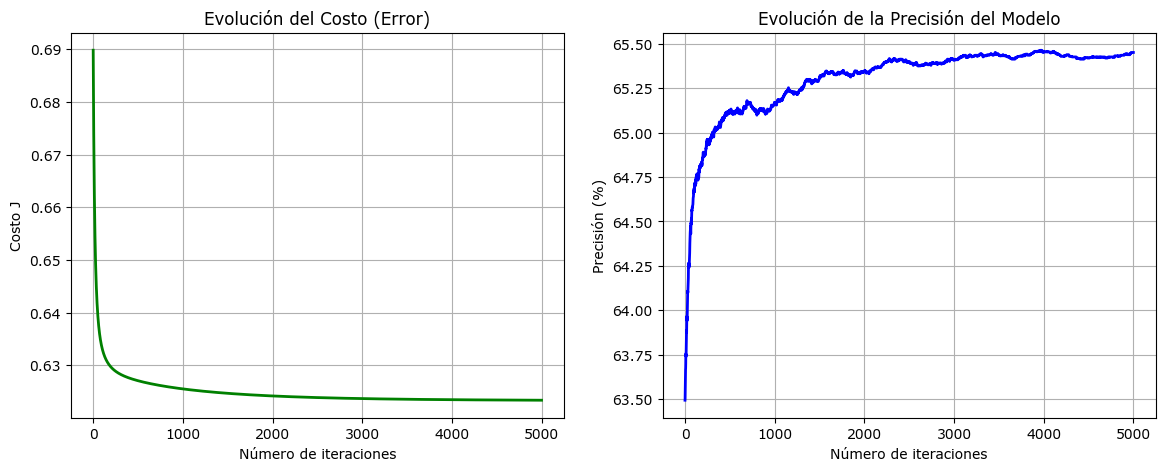

Theta calculado por el descenso por el gradiente (primeros 5 valores):
[ 0.16500499  0.00442956  0.05349548 -0.04842514  0.03367328]


In [73]:
# Elegir hiperparámetros (ajustados para un dataset masivo de >31,000 filas)
alpha = 0.05
num_iters = 5000

# Inicializa theta de forma DINÁMICA según el número de características (58 propiedades + 1 intercepción)
theta = np.zeros(X.shape[1])

# Ejecuta el descenso por el gradiente (ahora recuperamos 3 variables)
theta, J_history, acc_history = descensoGradiente(theta, X, y, alpha, num_iters)


# Graficar la convergencia del costo y de la precisión
# Creamos una figura con 2 subgráficos (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolución del Costo (J)
ax1.plot(np.arange(len(J_history)), J_history, lw=2, color='green')
ax1.set_xlabel('Número de iteraciones')
ax1.set_ylabel('Costo J')
ax1.set_title('Evolución del Costo (Error)')
ax1.grid(True)

# Gráfico 2: Evolución de la Precisión
ax2.plot(np.arange(len(acc_history)), acc_history, lw=2, color='blue')
ax2.set_xlabel('Número de iteraciones')
ax2.set_ylabel('Precisión (%)')
ax2.set_title('Evolución de la Precisión del Modelo')
ax2.grid(True)

plt.show()

# Muestra los resultados del descenso por el gradiente 
print('Theta calculado por el descenso por el gradiente (primeros 5 valores):')
print(theta[:5])

In [68]:
def predict(theta, X):
    m = X.shape[0]
    p = np.zeros(m)
    # Calcula la probabilidad y redondea (>= 0.5 se vuelve 1, < 0.5 se vuelve 0)
    p = np.round(sigmoid(X.dot(theta.T)))
    return p 

print(X_test)
print(theta)

[[ 1.20000000e+01  6.06000000e+02  4.92512478e-01 ... -4.00000000e-01
   1.00000000e-01  4.00000000e-01]
 [ 1.30000000e+01  1.69000000e+02  6.96428567e-01 ...  1.00000000e-01
   4.00000000e-01  1.00000000e-01]
 [ 8.00000000e+00  3.47000000e+02  6.04166665e-01 ...  6.00000000e-01
   5.00000000e-01  6.00000000e-01]
 ...
 [ 1.10000000e+01  1.72000000e+02  6.66666663e-01 ... -5.00000000e-02
   3.50000000e-01  5.00000000e-02]
 [ 7.00000000e+00  9.00000000e+01  8.65168530e-01 ...  2.50000000e-01
   0.00000000e+00  2.50000000e-01]
 [ 1.00000000e+01  2.90000000e+02  6.80701752e-01 ...  0.00000000e+00
   5.00000000e-01  0.00000000e+00]]
[ 0.16500499  0.00442956  0.05349548 -0.04842514  0.03367328 -0.06368036
  0.09853084 -0.06618939  0.02178845  0.01400381 -0.06820642  0.08474464
 -0.03128954 -0.11759826 -0.06789343  0.20054121  0.20064367  0.01104507
  0.12848974  0.08190884 -0.11584349 -0.04340533 -0.07075372 -0.06993527
 -0.075608   -0.51500837  0.8894959   0.10462611  0.00514724  0.0826511


In [69]:



# 1. Mostrar los datos de prueba (ya separados dinámicamente arriba con 'limite' y 'n_cols')
print("Datos de prueba (X_test) - Primeros 2 artículos:")
print(X_test[:2])

Datos de prueba (X_test) - Primeros 2 artículos:
[[ 1.20000000e+01  6.06000000e+02  4.92512478e-01  9.99999997e-01
   6.45161289e-01  1.20000000e+01  9.00000000e+00  3.00000000e+00
   0.00000000e+00  4.81353135e+00  1.00000000e+01  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00 -1.00000000e+00  3.09000000e+02  7.38000000e+01
   3.75000000e+04  8.43300000e+05  3.80040000e+05  1.97349521e+03
   4.50442562e+03  3.11126358e+03  9.68000000e+02  3.60000000e+03
   2.14720000e+03  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  4.45069932e-01  2.00010370e-02  2.00354015e-02
   2.01466837e-02  4.94746946e-01  4.73732934e-01  6.21894772e-02
   4.12541254e-02  1.98019802e-02  6.75675676e-01  3.24324324e-01
   3.22359307e-01  3.33333333e-02  6.00000000e-01 -3.34722222e-01
  -8.00000000e-01 -1.00000000e-01  6.00000000e-01 -4.00000000e-01
   1.00000000e-01  4.000000

In [71]:
# --- EVALUACIÓN EN ENTRENAMIENTO ---
p_train = predict(theta, X)
print('Precisión sobre los datos de entrenamiento: {:.2f} %\n'.format(np.mean(p_train == y_entrenamiento) * 100))


# 2. Comprobar si los artículos del dataset de prueba serán POPULARES
# OJO: Normalizamos usando estrictamente el 'mu' y 'sigma' del conjunto de entrenamiento
X_test_norm_formula = (X_test - mu) / sigma

m_test, n_test = X_test_norm_formula.shape
X_test_norm_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm_formula], axis=1)

# Calculamos las probabilidades de popularidad para TODOS los artículos de prueba
probabilidades = sigmoid(np.dot(X_test_norm_ready, theta))
print("\nProbabilidades calculadas para el conjunto de prueba (primeros 5 valores):")
print(probabilidades[:5])

Precisión sobre los datos de entrenamiento: 65.45 %


Probabilidades calculadas para el conjunto de prueba (primeros 5 valores):
[0.69017073 0.72824736 0.35257674 0.35883483 0.68855542]


In [65]:
# 3. Verificación de las matrices y prueba individual
print("\nMatriz X_test normalizada con intercepción (primeros 2 artículos):")
print(X_test_norm_ready[:2])

print("\nParámetros Theta (primeros 5 valores):")
print(theta[:5])

# Predicción para un artículo específico (el primero de nuestro conjunto de prueba)
predict_individual = sigmoid(np.dot(X_test_norm_ready[0], theta))

print('\n======================================================')
print('PREDICCIÓN INDIVIDUAL DE UN ARTÍCULO')
print('======================================================')
print('Un artículo de noticias con las características de X_test[0]')
print('tiene una probabilidad de ser POPULAR (>= 1400 shares) de: {:.0f}%'.format(predict_individual * 100))
print('El valor REAL de este artículo en el dataset es: {:.0f} (1=Popular, 0=No Popular)'.format(y_test[0]))


Matriz X_test normalizada con intercepción (primeros 2 artículos):
[[ 1.          0.76066508  0.13245406 -0.2789213   0.1754387  -0.18045205
   0.10047246  1.49794972 -0.18311525 -0.30267733  0.31529451  1.45662151
  -0.23568657 -0.46753514 -0.43267217 -0.2489598   2.0915336  -0.51856006
  -0.38925234 -0.21211639 -0.38111402  0.41476558  0.42434362  0.89306871
   0.75479096 -0.1848952  -0.01522723 -0.15349712 -0.16420732 -0.17510547
   2.22894531 -0.47672392 -0.47896401 -0.47428159 -0.41277303 -0.25811638
  -0.27221622 -0.38903321  0.99225673 -0.55319596 -0.69510798 -0.68817447
   0.90153957  0.26100811 -0.58683944  0.09524249  0.29147631 -0.0325919
   0.2315135  -0.29946807 -0.87069058 -0.63064723 -0.59232319 -0.96035346
   0.0779204   0.98309131 -1.76983497 -1.27954908  1.07998198]
 [ 1.          1.23334216 -0.80185948  1.20839226  0.17543866  0.92029995
  -0.43072627 -0.33340658 -0.54445046 -0.30267733  0.31188582  1.45662151
  -0.23568657 -0.46753514 -0.43267217 -0.2489598   2.091